In [2]:
import os
import sys

from copy import deepcopy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
path_this = os.path.dirname(os.path.abspath(__name__))
path_root= os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

In [40]:
import pandas as pd

df_dataset = pd.read_csv(os.path.join(path_dataset,'dataset.csv'))
# df_backup = deepcopy(df_dataset)
df_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
feature_desc = {
	"categorical": [
		# Membership Details
		'customerID', 'Contract', 'PaymentMethod', 'PaperlessBilling',
		# Demograph
		'gender', 'SeniorCitizen', 'Partner', 'Dependents',
		# Service
		'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
		'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PhoneService',
		# target 
		'Churn'],
	"numeric": ['tenure', 'MonthlyCharges', 'TotalCharges']
}

# Standardizing Data

In [43]:
df_dataset['TotalCharges'] = pd.to_numeric(df_dataset['TotalCharges'], errors='coerce')
df_dataset['Churn'] = df_dataset['Churn'].map({"No": 0, "Yes": 1})

In [44]:
df_dataset = df_dataset.loc[df_dataset['tenure'] != 0].reset_index(drop=True)
df_dataset.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Logistic Regression Model

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
	accuracy_score, recall_score, precision_score, f1_score, confusion_matrix,
	classification_report, roc_auc_score, log_loss, RocCurveDisplay)

scaler = StandardScaler()

In [46]:
# ========================
useful_features = [
	'MonthlyCharges', 'tenure', 'PaymentMethod', 'TechSupport',
	'OnlineSecurity', 'Contract', 'PhoneService'
]
# ========================

In [47]:
df_logreg = deepcopy(df_dataset)
# df_logreg['monthly_div_tenure'] = df_dataset['MonthlyCharges'] / df_dataset['tenure']

In [51]:
df_logreg.loc[df_logreg['Churn'] == 1].value_counts(subset=['InternetService', 'OnlineSecurity'], normalize=True)

InternetService  OnlineSecurity     
Fiber optic      No                     0.596041
DSL              No                     0.185661
Fiber optic      Yes                    0.097913
No               No internet service    0.060460
DSL              Yes                    0.059925
Name: proportion, dtype: float64

In [75]:
X = df_logreg.drop(
	columns=['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'TotalCharges'])# + [
		# ])
	# 'SeniorCitizen', 'gender', 'PaperlessBilling', 'customerID', 'Churn',
	# 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
	# 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
	# 'Contract', 'PaymentMethod', 
	# 'Partner', 'Dependents', 'PhoneService'
	# ])
# X = df_logreg.loc[:, ['tenure', 'Contract', 'PhoneService']]
y = df_logreg['Churn']

In [76]:
X.columns

Index(['tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges'],
      dtype='object')

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y)

In [78]:
numeric_features = ['tenure', 'MonthlyCharges']
# categorical_features = [
# 	'PaymentMethod', 'TechSupport','OnlineSecurity', 
# 	'Contract', 'PhoneService']
# numeric_features = ['tenure', 'MonthlyCharges']
categorical_features = [
	'Contract', 'PhoneService',
	# 'SeniorCitizen', 'gender', 'Partner', 'Dependents', 
	'PaperlessBilling', 'MultipleLines', 'InternetService', 
	'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
	'StreamingTV', 'StreamingMovies', 'TechSupport', 
	'Contract', 'PaymentMethod', 'PhoneService']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)


In [79]:
log_reg = LogisticRegression(
    l1_ratio=0,
    solver="lbfgs",
	# class_weight=None,
    # solver="liblinear",
    max_iter=1000
)
# {'model__C': 10, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}
base_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", log_reg)
    ]
)

base_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [80]:
y_proba = base_pipeline.predict_proba(X_test)[:, 1]
y_pred = base_pipeline.predict(X_test)
# y_pred = (y_proba >= 0.35).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC AUC: 0.8341637719947611
Log Loss: 0.4285492950076759

Confusion Matrix:
 [[910 123]
 [169 205]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



In [81]:
import numpy as np

thresholds = np.linspace(0.1, 0.5, 50)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

best_t, best_f1

(np.float64(0.3285714285714286), 0.6308571428571429)

In [82]:
y_proba = base_pipeline.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC AUC: 0.8341637719947611
Log Loss: 0.4285492950076759

Confusion Matrix:
 [[808 225]
 [ 98 276]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



## Find the best param

In [83]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "model__C": [0.01, 0.1, 1, 2, 3, 4, 5, 10, 100],
    "model__l1_ratio": [0, 1],
    "model__class_weight": [None, "balanced"],
	# "model__max_iter": [500, 1000, 1500, 2000],
    "model__solver": ["liblinear"]  # needed for l1
}


grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [84]:
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)


Best parameters: {'model__C': 10, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}


In [85]:
y_proba = base_pipeline.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC AUC: 0.8341637719947611
Log Loss: 0.4285492950076759

Confusion Matrix:
 [[808 225]
 [ 98 276]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [86]:
y_proba = best_model.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC AUC: 0.8334597325685533
Log Loss: 0.42937335154130585

Confusion Matrix:
 [[807 226]
 [ 99 275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [87]:
best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

best_t, best_f1

(np.float64(0.3285714285714286), 0.6285714285714286)

In [88]:
y_proba = base_pipeline.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC AUC: 0.8341637719947611
Log Loss: 0.4285492950076759

Confusion Matrix:
 [[808 225]
 [ 98 276]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [89]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",  # or "sigmoid" if data is small
    cv=3
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...liblinear'))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [90]:
y_proba = calibrated_model.predict_proba(X_test)[:, 1]
# y_pred = calibrated_model.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7697228144989339
Precision: 0.55
Recall: 0.7352941176470589
F1 Score: 0.6292906178489702
ROC AUC: 0.8336046818621844
Log Loss: 0.4288949019673544

Confusion Matrix:
 [[808 225]
 [ 99 275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

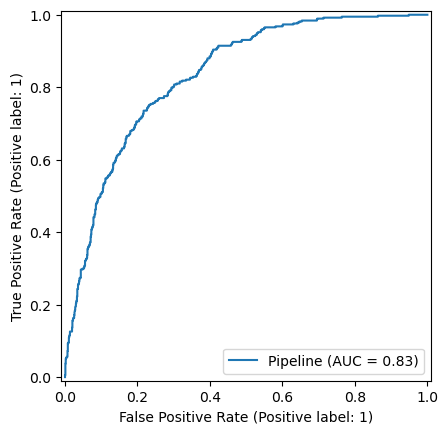

In [91]:
# fpr, tpr, thresholds = roc_curve(y_test, y_proba_opt)
# plt.plot([0, 1], [0, 1], 'k--' )
# plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Logistic Regression ROC Curve',fontsize=16)
# plt.show();

roc_logreg = RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

---

In [92]:
ohe = best_model.named_steps["preprocessing"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([
    numeric_features,
    cat_features
])

In [93]:
coefficients = best_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})
coef_df = coef_df.loc[coef_df['coefficient'] != 0]
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df = coef_df.sort_values(by='coefficient', ascending=False)
# coef_df.to_excel("coef.xlsx", index=False)
coef_df


,feature,coefficient,odds_ratio
8,InternetService_Fiber optic,2.121385,8.342683
17,StreamingTV_Yes,0.770151,2.160092
19,StreamingMovies_Yes,0.754815,2.127217
7,MultipleLines_Yes,0.586179,1.797108
25,PaymentMethod_Electronic check,0.408912,1.505179
5,PaperlessBilling_Yes,0.303984,1.355247
15,DeviceProtection_Yes,0.286352,1.331561
26,PaymentMethod_Mailed check,0.126523,1.134876
13,OnlineBackup_Yes,0.079324,1.082555
24,PaymentMethod_Credit card (automatic),0.049534,1.050781


In [ ]:
from sklearn.model_selection import StratifiedKFold

coefs = []

for train_idx, test_idx in skf.split(X=X, y=y):
    best_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    coefs.append(best_model.coef_[0])

coef_matrix = pd.DataFrame(coefs, columns=feature_names)
coef_matrix


TypeError: StratifiedKFold.split() missing 1 required positional argument: 'self'

In [71]:
df_dataset.value_counts(subset=['InternetService', 'Churn'], normalize=True)

InternetService  Churn
DSL              0        0.278299
Fiber optic      0        0.255830
No               0        0.200085
Fiber optic      1        0.184443
DSL              1        0.065273
No               1        0.016069
Name: proportion, dtype: float64

In [72]:
# sns.boxplot(df_dataset, x='InternetService', y='MonthlyCharges', hue='Churn')

In [94]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "model__C": [0.01, 0.1, 1, 2, 3, 4, 5, 10, 100, 1000],
    "model__l1_ratio": [0, 1],
    "model__class_weight": [None, "balanced"],
	# "model__max_iter": [500, 1000, 1500, 2000],
    "model__solver": ["liblinear"]  # needed for l1
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring="neg_log_loss",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [95]:
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)


Best parameters: {'model__C': 100, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}


In [96]:
import numpy as np

thresholds = np.linspace(0.1, 0.5, 50)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

best_t, best_f1

(np.float64(0.3285714285714286), 0.6292906178489702)

In [30]:
y_proba = best_model.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC AUC: 0.8329834706037654
Log Loss: 0.4299547237339531

Confusion Matrix:
 [[806 227]
 [100 274]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [60]:
coefs = []

for train_idx, test_idx in cv.split(X=X, y=y):
    best_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    coefs.append(best_model.named_steps["model"].coef_[0])

coef_matrix = pd.DataFrame(coefs, columns=feature_names)
coef_matrix = coef_matrix.T
# coef_matrix = coef_matrix.describe().T.sort_values(by='mean', ascending=False)
# coef_matrix['mean']
coef_matrix['mean_abs'] = coef_matrix.apply(abs, axis=1).mean(axis=1)
coef_matrix['std'] = coef_matrix.drop(columns='mean_abs').apply(np.std, axis=1)
coef_matrix

,0,1,2,3,4,mean_abs,std
tenure,-0.848020,-0.854897,-0.834523,-0.841699,-0.802326,0.836293,0.018274
MonthlyCharges,-0.810148,-0.918100,-1.868559,-0.798610,0.019489,0.882981,0.599861
PaperlessBilling_Yes,0.337552,0.271108,0.352065,0.425704,0.360954,0.349477,0.049463
MultipleLines_No phone service,-0.739827,-0.856194,-1.523944,-0.901439,-0.213786,0.847038,0.418030
MultipleLines_Yes,0.507621,0.422338,0.589152,0.453318,0.319574,0.458401,0.089574
InternetService_Fiber optic,1.577549,1.697272,2.545451,1.556283,0.943905,1.664092,0.512967
InternetService_No,-0.207027,-0.236731,-0.341281,-0.215422,-0.104186,0.220929,0.075613
OnlineSecurity_No internet service,-0.207027,-0.236731,-0.341281,-0.215422,-0.104186,0.220929,0.075613
OnlineSecurity_Yes,-0.263086,-0.235673,-0.098310,-0.243148,-0.300661,0.228176,0.068729
OnlineBackup_No internet service,-0.207027,-0.236731,-0.341281,-0.215422,-0.104186,0.220929,0.075613


In [94]:
coef_matrix.loc[
	(coef_matrix['std'] <=0.3) 
	# (coef_matrix['mean_abs'] >= 0.65)
].sort_values(by='mean_abs', ascending=False)

,0,1,2,3,4,mean_abs,std
Contract_Two year,-1.278508,-1.335891,-1.355249,-1.337400,-1.655195,1.392448,0.133889
tenure,-0.848020,-0.854897,-0.834523,-0.841699,-0.802326,0.836293,0.018274
PhoneService_Yes,-0.835848,-0.758364,-0.760104,-0.766010,-0.787535,0.781572,0.029062
Contract_One year,-0.784469,-0.655664,-0.639613,-0.708694,-0.688885,0.695465,0.050683
StreamingMovies_Yes,0.653534,0.574319,0.913087,0.538796,0.213412,0.578630,0.224705
StreamingTV_Yes,0.540807,0.622410,0.857937,0.540229,0.208858,0.554048,0.208108
MultipleLines_Yes,0.507621,0.422338,0.589152,0.453318,0.319574,0.458401,0.089574
PaperlessBilling_Yes,0.337552,0.271108,0.352065,0.425704,0.360954,0.349477,0.049463
PaymentMethod_Electronic check,0.310747,0.326630,0.308866,0.380828,0.312502,0.327915,0.027190
OnlineSecurity_Yes,-0.263086,-0.235673,-0.098310,-0.243148,-0.300661,0.228176,0.068729
